# Clustering (K-Means)
## Amazon Best Sellers — Segmentasi Buku Berdasarkan Rating, Reviews, dan Price

Dari EDA (`01_eda.ipynb`) diketahui bahwa `User Rating` cenderung seragam tinggi, sedangkan `Reviews` dan `Price` jauh lebih bervariasi dan hampir tidak berkorelasi satu sama lain. Notebook ini menggunakan **K-Means** pada ketiga fitur tersebut untuk menemukan segmen/kelompok buku bestseller yang punya karakteristik serupa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/bestsellers.csv')
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


## 2. Feature Selection & Scaling

In [3]:
features = ['User Rating', 'Reviews', 'Price']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).describe().round(2)

,User Rating,Reviews,Price
count,550.00,550.00,550.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-5.81,-1.02,-1.21
25%,-0.52,-0.67,-0.56
50%,0.36,-0.29,-0.19
75%,0.80,0.45,0.27
max,1.24,6.47,8.48


**Kenapa perlu scaling?** `Reviews` berskala ribuan, `Price` puluhan, `User Rating` hanya 0-5. Tanpa standardisasi, K-Means (yang berbasis jarak Euclidean) akan didominasi sepenuhnya oleh `Reviews`.

## 3. Menentukan Jumlah Cluster (Elbow Method + Silhouette Score)

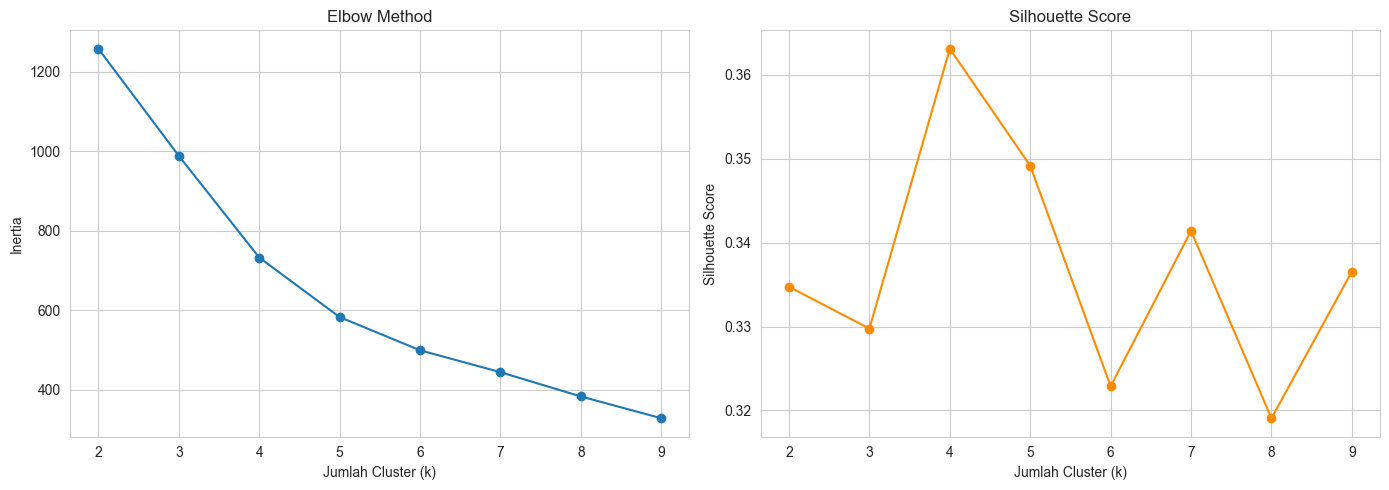

,k,inertia,silhouette
0,2,1257.737420,0.334740
1,3,988.344487,0.329754
2,4,732.636438,0.363106
3,5,582.846002,0.349165
4,6,499.367981,0.322880
5,7,444.269367,0.341406
6,8,383.196279,0.319066
7,9,328.417438,0.336545


In [4]:
k_range = range(2, 10)
inertia = []
silhouette = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(list(k_range), inertia, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Jumlah Cluster (k)')
ax[0].set_ylabel('Inertia')
ax[0].grid(True)

ax[1].plot(list(k_range), silhouette, marker='o', color='darkorange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Jumlah Cluster (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertia, 'silhouette': silhouette})

**Keputusan jumlah cluster**: Elbow method tidak menunjukkan titik siku (elbow) yang sangat jelas karena nilai inertia menurun secara bertahap seiring bertambahnya jumlah cluster. Oleh karena itu, pemilihan jumlah cluster juga mempertimbangkan Silhouette Score. Meskipun nilai Silhouette Score tertinggi diperoleh pada k = 4 (≈0,363), perbedaannya dengan k = 5 (≈0,349) relatif kecil. Oleh karena itu, penelitian ini menggunakan k = 5 karena memberikan segmentasi yang lebih rinci tanpa mengurangi kualitas pemisahan cluster secara signifikan, sehingga hasilnya lebih mudah dimanfaatkan untuk analisis karakteristik masing-masing kelompok.

In [5]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Name', 'User Rating', 'Reviews', 'Price', 'Genre', 'Cluster']].head()

,Name,User Rating,Reviews,Price,Genre,Cluster
0,10-Day Green Smoothie Cleanse,4.7,17350,8,Non Fiction,1
1,11/22/63: A Novel,4.6,2052,22,Fiction,0
2,12 Rules for Life: An Antidote to Chaos,4.7,18979,15,Non Fiction,1
3,1984 (Signet Classics),4.7,21424,6,Fiction,1
4,"5,000 Awesome Facts (About Everything!) (Natio...",4.8,7665,12,Non Fiction,0


## 4. Profil Tiap Cluster

In [6]:
cluster_summary = df.groupby('Cluster').agg(
    Rating_mean=('User Rating', 'mean'),
    Reviews_mean=('Reviews', 'mean'),
    Price_mean=('Price', 'mean'),
    Count=('Name', 'count')
).round(2)

cluster_summary

,Rating_mean,Reviews_mean,Price_mean,Count
Cluster,,,,
0,4.69,5878.49,11.80,281
1,4.73,21798.08,9.63,144
2,4.41,58490.38,11.69,16
3,4.24,7951.47,12.31,83
4,4.54,7219.54,49.69,26


In [7]:
reviews_mean_global = df['Reviews'].mean()
reviews_std_global = df['Reviews'].std()
price_mean_global = df['Price'].mean()
price_std_global = df['Price'].std()
rating_mean_global = df['User Rating'].mean()
rating_std_global = df['User Rating'].std()

def label_cluster(row):
    if row['Price_mean'] > price_mean_global + price_std_global:
        return 'Buku Premium (Harga Sangat Tinggi)'
    if row['Reviews_mean'] > reviews_mean_global + reviews_std_global:
        return 'Buku Sangat Viral (Reviews Ekstrem)'
    if row['Rating_mean'] < rating_mean_global - rating_std_global:
        return 'Buku Rating Rendah'
    if row['Reviews_mean'] > reviews_mean_global:
        return 'Buku Populer (Review Tinggi, Harga Terjangkau)'
    return 'Buku Umum (Review & Harga Sedang)'

cluster_summary['Label'] = cluster_summary.apply(label_cluster, axis=1)
label_map = cluster_summary['Label'].to_dict()

df['Cluster_Label'] = df['Cluster'].map(label_map)

assert df['Cluster_Label'].isnull().sum() == 0, 'Ada cluster tanpa label!'
n_clusters = df['Cluster'].nunique()
n_labels = cluster_summary['Label'].nunique()
if n_labels < n_clusters:
    print(f'Peringatan: {n_clusters} cluster hanya menghasilkan {n_labels} label unik.')
else:
    print(f'OK: seluruh {n_clusters} cluster punya label yang unik.')

cluster_summary

OK: seluruh 5 cluster punya label yang unik.


,Rating_mean,Reviews_mean,Price_mean,Count,Label
Cluster,,,,,
0,4.69,5878.49,11.80,281,Buku Umum (Review & Harga Sedang)
1,4.73,21798.08,9.63,144,"Buku Populer (Review Tinggi, Harga Terjangkau)"
2,4.41,58490.38,11.69,16,Buku Sangat Viral (Reviews Ekstrem)
3,4.24,7951.47,12.31,83,Buku Rating Rendah
4,4.54,7219.54,49.69,26,Buku Premium (Harga Sangat Tinggi)


## 5. Komposisi Genre per Cluster

In [8]:
pd.crosstab(df['Cluster_Label'], df['Genre'])

Genre,Fiction,Non Fiction
Cluster_Label,,
"Buku Populer (Review Tinggi, Harga Terjangkau)",83,61
Buku Premium (Harga Sangat Tinggi),5,21
Buku Rating Rendah,31,52
Buku Sangat Viral (Reviews Ekstrem),14,2
Buku Umum (Review & Harga Sedang),107,174


## 6. Visualisasi Cluster

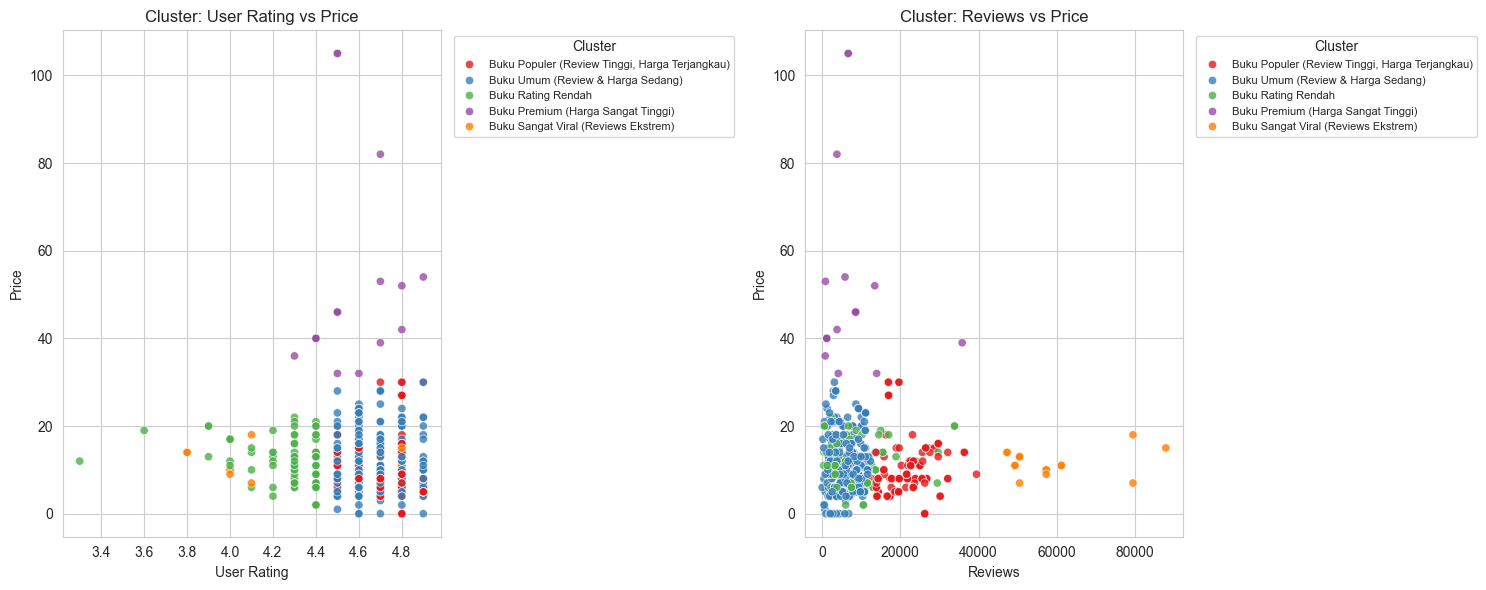

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='User Rating', y='Price', hue='Cluster_Label', palette='Set1', ax=ax[0], alpha=0.8)
ax[0].set_title('Cluster: User Rating vs Price')
ax[0].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

sns.scatterplot(data=df, x='Reviews', y='Price', hue='Cluster_Label', palette='Set1', ax=ax[1], alpha=0.8)
ax[1].set_title('Cluster: Reviews vs Price')
ax[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

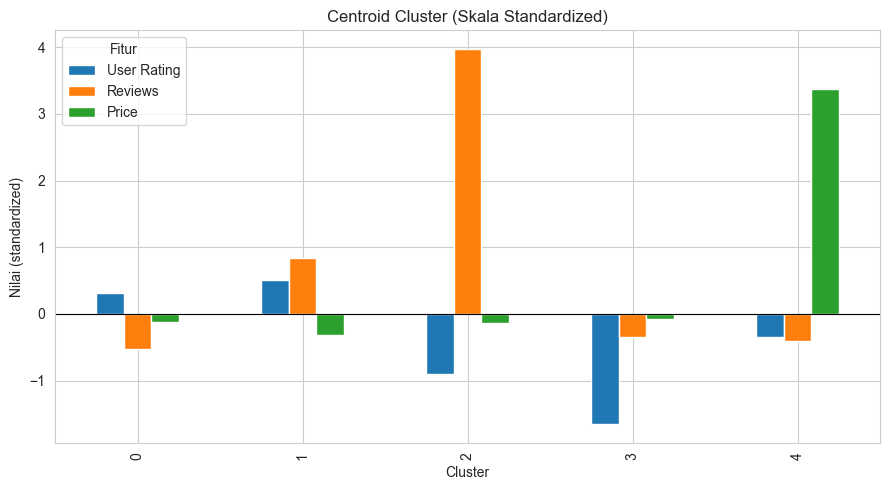

In [10]:
# Perbandingan centroid (dalam skala ter-standardisasi) antar cluster
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids.index.name = 'Cluster'

centroids.plot(kind='bar', figsize=(9, 5))
plt.title('Centroid Cluster (Skala Standardized)')
plt.xlabel('Cluster')
plt.ylabel('Nilai (standardized)')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Fitur')
plt.tight_layout()
plt.show()

## 7. Simpan Hasil

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/bestsellers_clustered.csv', index=False)
print('Saved to ../data/processed/bestsellers_clustered.csv')

Saved to ../data/processed/bestsellers_clustered.csv


## Ringkasan Insight Clustering

1. **k=5** dipilih: silhouette tertinggi ada di k=4 (≈0.363), tapi selisihnya kecil dengan k=5 (≈0.349), sehingga k=5 dipakai karena memberi segmentasi lebih rinci tanpa mengorbankan kualitas pemisahan cluster secara signifikan.
2. **Price adalah pemisah cluster paling kuat** — cluster "Premium" terpisah jelas karena harga jauh di atas rata-rata, bukan karena rating atau jumlah review yang ekstrem.
3. **Ada segmen "Sangat Viral"** yang terpisah dari segmen "Populer" biasa — rata-rata reviews-nya jauh di atas cluster populer lain (bukan cuma di atas rata-rata keseluruhan), menunjukkan ada buku-buku fenomenal yang beda kelas dari bestseller pada umumnya.
4. **Rating relatif tidak membedakan cluster secara tajam**, konsisten dengan temuan EDA bahwa rating buku bestseller cenderung seragam tinggi — kecuali satu cluster kecil dengan rating jelas di bawah rata-rata ("Rating Rendah").
5. Label cluster dibuat otomatis dari centroid dengan **threshold bertingkat** (mean & mean+1 std), memastikan seluruh cluster punya label unik